# BEGINNING

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import seaborn as sns
from scipy import stats

In [ ]:
df = pd.read_csv("MAO_B_analysis_raw.csv", sep=";")
df.head()

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
0,CHEMBL4083836,NaN,NaN,380.53,1.0,5.03,TM-31,CCN(CCCCCCOc1ccc2c(c1)NC(=O)CC2)Cc1ccccc1,IC50,'=',...,CHEMBL4033676,1,Scientific Literature,Bioorg Med Chem,2017,NaN,NaN,NaN,NaN,1.70
1,CHEMBL92401,IPRONIAZID,2.0,179.22,0.0,0.72,Iproniazid,CC(C)NNC(=O)c1ccncc1,IC50,'=',...,CHEMBL4033676,1,Scientific Literature,Bioorg Med Chem,2017,NaN,NaN,NaN,NaN,1.78
2,CHEMBL5758556,NaN,NaN,270.42,0.0,3.01,BDBM256497,c1cc([C@H]2C[C@@H]2NCC2CCNCC2)ccc1C1CC1,IC50,'=',...,CHEMBL5727123,37,BindingDB Patent Bioactivity Data,NaN,2019,NaN,NaN,NaN,NaN,3790.00
3,CHEMBL5936973,NaN,NaN,296.42,0.0,2.52,BDBM256499,c1cc(-c2ccc([C@H]3C[C@@H]3NCC3CCNCC3)cc2)[nH]n1,IC50,'>',...,CHEMBL5727123,37,BindingDB Patent Bioactivity Data,NaN,2019,NaN,NaN,NaN,NaN,100000.00
4,CHEMBL5829534,NaN,NaN,223.35,0.0,1.34,BDBM256473,c1ncc([C@H]2C[C@@H]2NC2CCNCC2)s1,IC50,'>',...,CHEMBL5727123,37,BindingDB Patent Bioactivity Data,NaN,2019,NaN,NaN,NaN,NaN,100000.00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8656 entries, 0 to 8655
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Molecule ChEMBL ID          8656 non-null   object 
 1   Molecule Name               757 non-null    object 
 2   Molecule Max Phase          641 non-null    float64
 3   Molecular Weight            8649 non-null   float64
 4   #RO5 Violations             8600 non-null   float64
 5   AlogP                       8600 non-null   float64
 6   Compound Key                8656 non-null   object 
 7   Smiles                      8649 non-null   object 
 8   Standard Type               8656 non-null   object 
 9   Standard Relation           8426 non-null   object 
 10  Standard Value              8426 non-null   float64
 11  Standard Units              8432 non-null   object 
 12  pChEMBL Value               5560 non-null   float64
 13  Data Validity Comment       402 n

In [ ]:
df.shape

(8656, 48)

# DATA PREPARATION

Очистка таргета

Удаление дубликатов

Заполнение пропусков

TIME = … hr в числовую колонку

Проверка типа данных

In [ ]:
df_proc = df.copy()

print("NaN in Standard Value before:", df_proc['Standard Value'].isna().sum())
df_proc = df_proc[df_proc['Standard Value'].notna()].copy()
print("After:", df_proc['Standard Value'].isna().sum())
print("Dataset shape:", df_proc.shape)

NaN in Standard Value before: 230
After: 0
Dataset shape: (8426, 48)


In [ ]:
print(df_proc['Standard Relation'].unique())
df_proc['Standard Relation'] = df_proc['Standard Relation'].str.strip().str.replace("'", "")
print(df_proc['Standard Relation'].unique())

["'='" "'>'" "'<'" "'>='"]
['=' '>' '<' '>=']


In [ ]:
known = df_proc[df_proc['Standard Relation'] == '=']['Standard Value'].dropna()
min_pchembl = (-np.log10(known * 1e-9)).min()

def pchembl_with_bounds(row):
    if row['Standard Relation'] == '=' and pd.notna(row['Standard Value']):
        return -np.log10(row['Standard Value'] * 1e-9)
    elif row['Standard Relation'] == '>' and pd.notna(row['Standard Value']):
        return min_pchembl
    else:
        return np.nan

df_proc['pChEMBL Value'] = df_proc.apply(pchembl_with_bounds, axis=1)
print("Number of NaN in pChEMBL Value:", df_proc['pChEMBL Value'].isna().sum())


Number of NaN in pChEMBL Value: 79


In [ ]:
def first_not_null(series):
    non_null = series.dropna()
    return non_null.iloc[0] if not non_null.empty else np.nan

df_analysis = (
    df_proc
    .groupby(['Smiles', 'Molecular Weight'], as_index=False)
    .agg({
        'Molecule ChEMBL ID': 'first',
        'pChEMBL Value': 'mean',
        'Molecular Weight': first_not_null,
        'AlogP': first_not_null,
        '#RO5 Violations': first_not_null,
        'Document Year': first_not_null,
        'Source Description': first_not_null
    })
)

print(df_analysis.shape)
print(df_analysis.isna().sum())

(5983, 8)
Smiles                 0
Molecule ChEMBL ID     0
pChEMBL Value         74
Molecular Weight       0
AlogP                 25
#RO5 Violations       25
Document Year          0
Source Description     0
dtype: int64


In [ ]:
df_analysis = df_analysis.dropna(subset=['pChEMBL Value', 'AlogP', '#RO5 Violations'])
print(df_analysis[['pChEMBL Value', 'AlogP', '#RO5 Violations']].isna().sum())

pChEMBL Value      0
AlogP              0
#RO5 Violations    0
dtype: int64


In [ ]:
df_analysis['Time_hr'] = (
    df_proc['Properties']
    .str.extract(r'TIME\s*=\s*([\d.]+)\s*hr', expand=False)
    .astype(float)
)

print(df_analysis['Time_hr'].value_counts(dropna=False))

Time_hr
NaN        5355
0.33330      95
0.25000      93
0.50000      68
1.00000      63
0.58330      55
1.50000      38
1.25000      30
0.16670      27
0.66670      17
0.41670      14
0.83330      14
0.75000       5
0.08333       5
1.33300       4
1.16700       1
Name: count, dtype: int64


In [ ]:
display(df_analysis)

,Smiles,Molecule ChEMBL ID,pChEMBL Value,Molecular Weight,AlogP,#RO5 Violations,Document Year,Source Description,Time_hr
0,Br.CCOC(=O)C(C(=O)N/N=C/c1ccc([N+](=O)[O-])cc1...,CHEMBL5434514,7.698970,488.32,2.29,0.0,2022,Scientific Literature,NaN
1,Br.CCOc1ccc(-c2n[nH]cc2C2=NCCN2)cc1,CHEMBL4465934,1.230000,337.22,1.83,0.0,2019,Scientific Literature,NaN
2,Br.COc1ccc(C2=NCCN2)cc1Cn1ccnc1C,CHEMBL4552404,1.230000,351.25,1.60,0.0,2019,Scientific Literature,NaN
3,Br.c1ccc(-n2cc(C3=NCCN3)c(-c3cccs3)n2)cc1,CHEMBL4517523,4.735182,375.30,2.95,0.0,2019,Scientific Literature,NaN
4,Brc1ccc(-c2cc3ccccc3o2)cc1,CHEMBL4290868,6.468521,273.13,4.86,0.0,2017,Scientific Literature,NaN
...,...,...,...,...,...,...,...,...,...
5978,c1cncc([C@H]2C[C@@H]2NC2CCNCC2)c1,CHEMBL5926950,1.230000,217.32,1.28,0.0,2018,BindingDB Patent Bioactivity Data,NaN
5979,c1csc(-c2cnc3c4cccnc4nn3c2)c1,CHEMBL4763130,5.348722,252.30,3.01,0.0,2021,Scientific Literature,NaN
5980,c1csc(-c2noc(-c3ccc(C4=NCCN4)cc3)n2)c1,CHEMBL4530181,6.050610,296.36,2.81,0.0,2019,Scientific Literature,NaN
5981,c1ncc([C@H]2C[C@@H]2NC2CCNCC2)s1,CHEMBL5829534,1.230000,223.35,1.34,0.0,2019,BindingDB Patent Bioactivity Data,NaN


In [ ]:
df_analysis['Source_Type'] = df_proc['Source Description'].apply(
    lambda x: 'Patent' if 'patent' in str(x).lower() else 'Article'
)

df_analysis['Journal'] = df_proc['Document Journal']
print(df_analysis[['Source_Type', 'Journal']].head(15))


   Source_Type          Journal
0      Article  Bioorg Med Chem
1      Article  Bioorg Med Chem
2       Patent              NaN
3       Patent              NaN
4       Patent              NaN
5      Article  Bioorg Med Chem
6      Article  Bioorg Med Chem
7      Article  Bioorg Med Chem
8      Article  Bioorg Med Chem
9      Article  Bioorg Med Chem
10     Article  Bioorg Med Chem
11     Article  Bioorg Med Chem
12     Article  Bioorg Med Chem
13     Article  Bioorg Med Chem
14     Article   Eur J Med Chem


In [ ]:
display(df_analysis)

,Smiles,Molecule ChEMBL ID,pChEMBL Value,Molecular Weight,AlogP,#RO5 Violations,Document Year,Source Description,Time_hr,Source_Type,Journal
0,Br.CCOC(=O)C(C(=O)N/N=C/c1ccc([N+](=O)[O-])cc1...,CHEMBL5434514,7.698970,488.32,2.29,0.0,2022,Scientific Literature,NaN,Article,Bioorg Med Chem
1,Br.CCOc1ccc(-c2n[nH]cc2C2=NCCN2)cc1,CHEMBL4465934,1.230000,337.22,1.83,0.0,2019,Scientific Literature,NaN,Article,Bioorg Med Chem
2,Br.COc1ccc(C2=NCCN2)cc1Cn1ccnc1C,CHEMBL4552404,1.230000,351.25,1.60,0.0,2019,Scientific Literature,NaN,Patent,NaN
3,Br.c1ccc(-n2cc(C3=NCCN3)c(-c3cccs3)n2)cc1,CHEMBL4517523,4.735182,375.30,2.95,0.0,2019,Scientific Literature,NaN,Patent,NaN
4,Brc1ccc(-c2cc3ccccc3o2)cc1,CHEMBL4290868,6.468521,273.13,4.86,0.0,2017,Scientific Literature,NaN,Patent,NaN
...,...,...,...,...,...,...,...,...,...,...,...
5978,c1cncc([C@H]2C[C@@H]2NC2CCNCC2)c1,CHEMBL5926950,1.230000,217.32,1.28,0.0,2018,BindingDB Patent Bioactivity Data,NaN,Article,Bioorg Med Chem Lett
5979,c1csc(-c2cnc3c4cccnc4nn3c2)c1,CHEMBL4763130,5.348722,252.30,3.01,0.0,2021,Scientific Literature,NaN,Article,J Med Chem
5980,c1csc(-c2noc(-c3ccc(C4=NCCN4)cc3)n2)c1,CHEMBL4530181,6.050610,296.36,2.81,0.0,2019,Scientific Literature,NaN,Patent,NaN
5981,c1ncc([C@H]2C[C@@H]2NC2CCNCC2)s1,CHEMBL5829534,1.230000,223.35,1.34,0.0,2019,BindingDB Patent Bioactivity Data,NaN,Patent,NaN


In [ ]:
df_analysis.shape

(5884, 11)

In [ ]:
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5884 entries, 0 to 5982
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Smiles              5884 non-null   object 
 1   Molecule ChEMBL ID  5884 non-null   object 
 2   pChEMBL Value       5884 non-null   float64
 3   Molecular Weight    5884 non-null   float64
 4   AlogP               5884 non-null   float64
 5   #RO5 Violations     5884 non-null   float64
 6   Document Year       5884 non-null   int64  
 7   Source Description  5884 non-null   object 
 8   Time_hr             529 non-null    float64
 9   Source_Type         5710 non-null   object 
 10  Journal             4442 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 551.6+ KB


In [ ]:
df_analysis.to_csv("mao_b_dataanalysis.csv", index=False)

# EDA and VISUALISATION

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# Преобразуем RO5 Violations в категориальную переменную
df_analysis['#RO5 Violations'] = df_analysis['#RO5 Violations'].astype('category')

# Проверяем типы колонок и пропуски
print("Data info:")
print(df_analysis.info())
print("\nMissing values per column:")
print(df_analysis.isna().sum())

# Статистическая сводка по числовым признакам
print("\nStatistical summary for numerical features:")
print(df_analysis.describe())

Data info:
<class 'pandas.core.frame.DataFrame'>
Index: 5884 entries, 0 to 5982
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Smiles              5884 non-null   object  
 1   pChEMBL Value       5884 non-null   float64 
 2   Molecular Weight    5884 non-null   float64 
 3   AlogP               5884 non-null   float64 
 4   #RO5 Violations     5884 non-null   category
 5   Document Year       5884 non-null   int64   
 6   Source Description  5884 non-null   object  
 7   Time_hr             526 non-null    float64 
 8   Source_Type         5635 non-null   object  
 9   Journal             4389 non-null   object  
dtypes: category(1), float64(4), int64(1), object(4)
memory usage: 465.6+ KB
None

Missing values per column:
Smiles                   0
pChEMBL Value            0
Molecular Weight         0
AlogP                    0
#RO5 Violations          0
Document Year            0
Source Descript

гистограммы

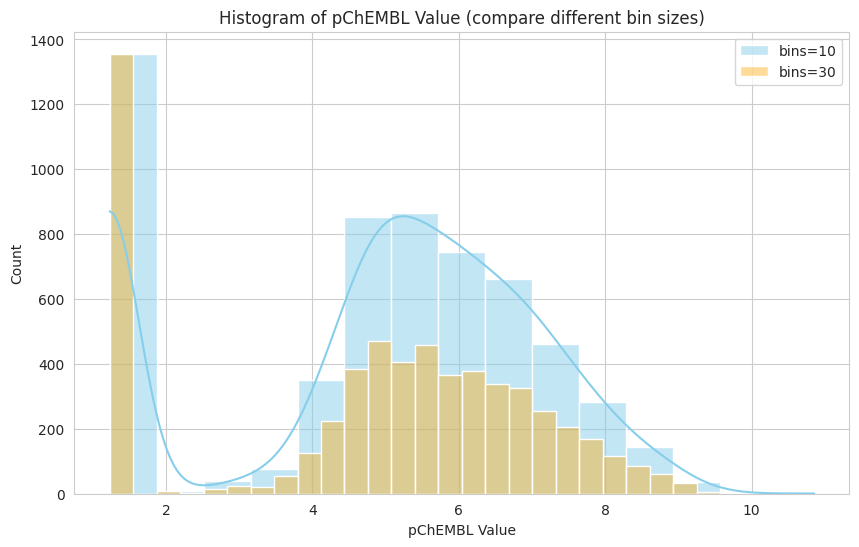

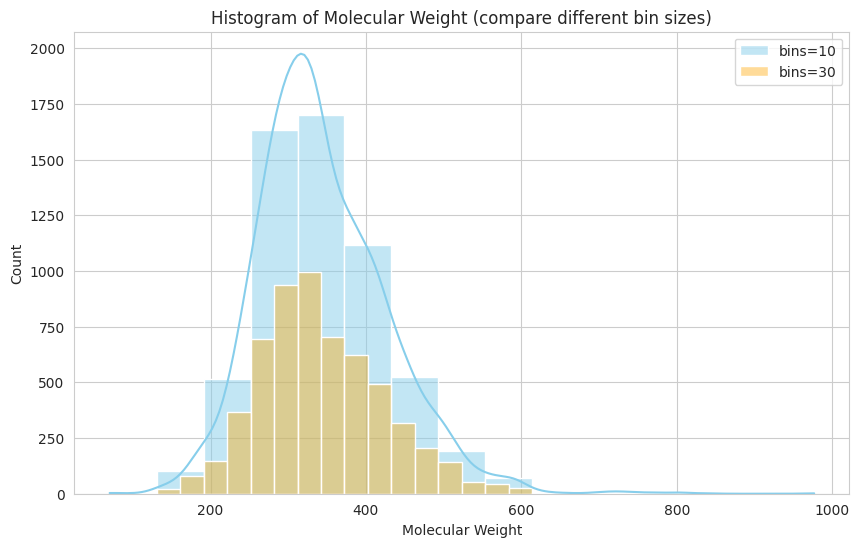

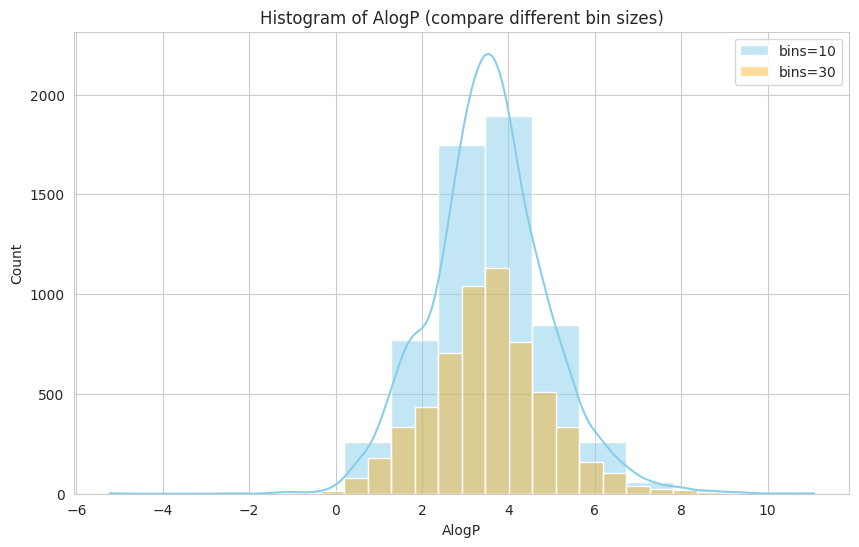

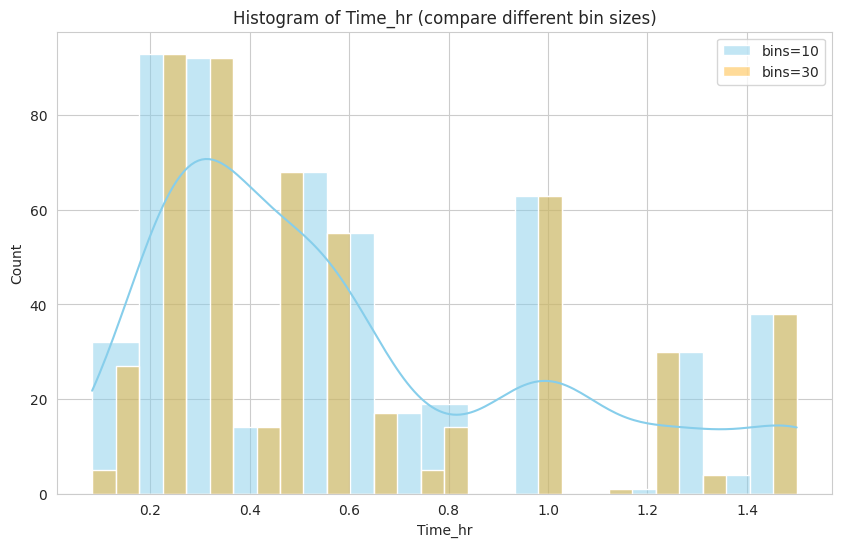

In [ ]:
numerical_cols = ['pChEMBL Value', 'Molecular Weight', 'AlogP', 'Time_hr']

for col in numerical_cols:
    plt.figure()
    sns.histplot(df_analysis[col].dropna(), bins=15, kde=True, color='skyblue', label='bins=10')
    sns.histplot(df_analysis[col].dropna(), bins=30, kde=False, color='orange', alpha=0.4, label='bins=30')
    plt.title(f'Histogram of {col} (compare different bin sizes)')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend()
    plt.show()

PIE CHART

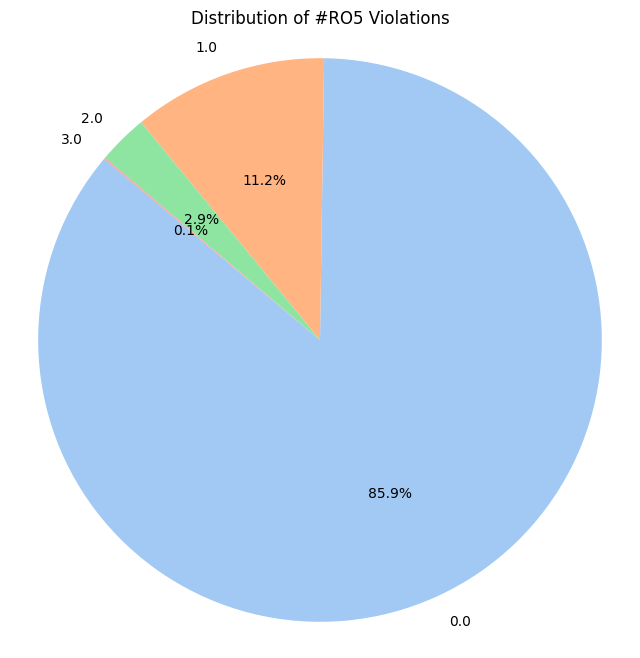

In [ ]:
ro5_counts = df_analysis['#RO5 Violations'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(ro5_counts, labels=ro5_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel', len(ro5_counts)))
plt.title('Distribution of #RO5 Violations')
plt.axis('equal')
plt.show()

BOX PLOTS + OUTLIERS

атомных единицах массы (а. е. м.)

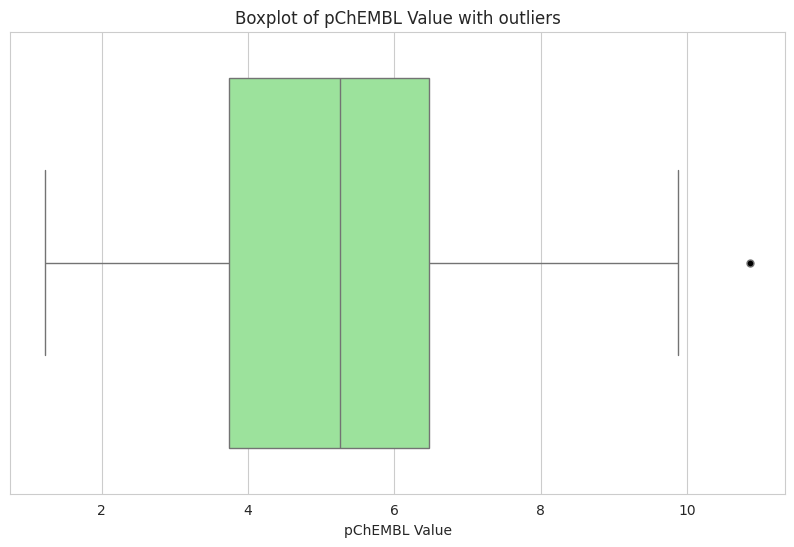

pChEMBL Value: Q1=3.739948343106322, Q2=5.2625648399965765, Q3=6.47074618931597, Outliers=1 (0.02%)


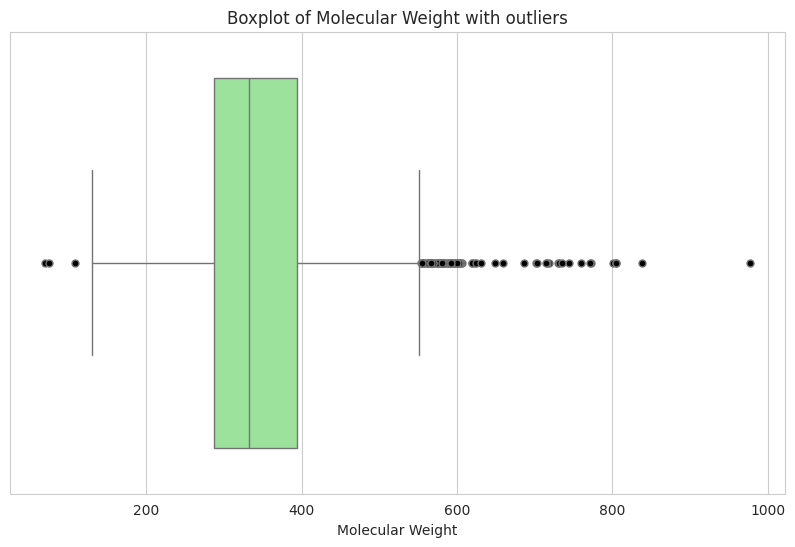

Molecular Weight: Q1=287.3525, Q2=331.76, Q3=393.54, Outliers=99 (1.68%)


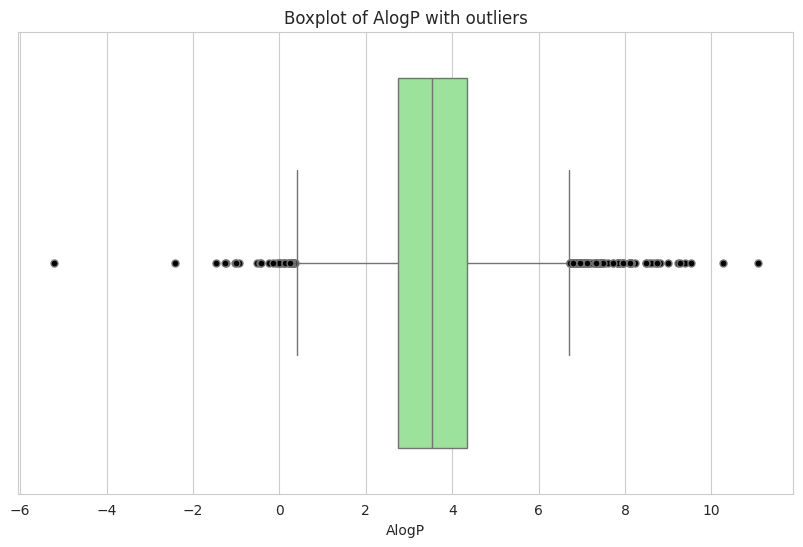

AlogP: Q1=2.75, Q2=3.53, Q3=4.34, Outliers=135 (2.29%)


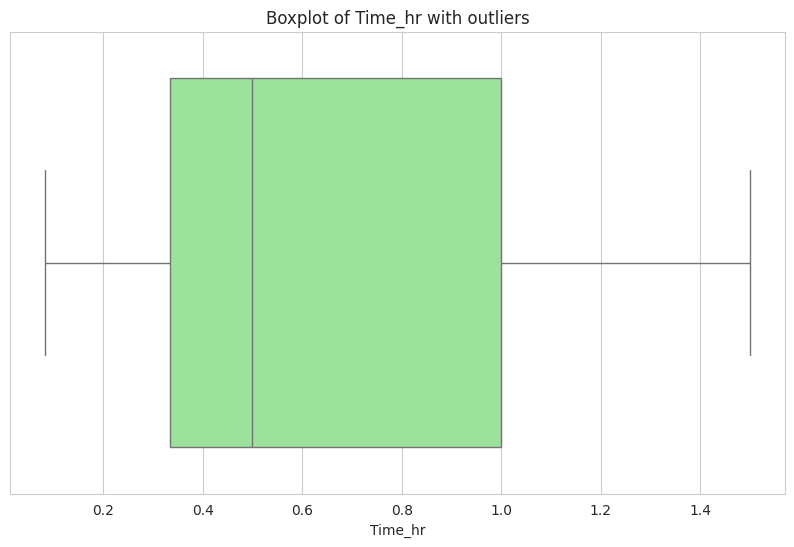

Time_hr: Q1=0.3333, Q2=0.5, Q3=1.0, Outliers=0 (0.00%)


In [ ]:
for col in numerical_cols:
    plt.figure()
    sns.boxplot(x=df_analysis[col].dropna(), color='lightgreen', flierprops=dict(marker='o', markerfacecolor='black', markersize=5))
    plt.title(f'Boxplot of {col} with outliers')
    plt.xlabel(col)
    plt.show()

    # Квантили и выбросы
    Q1 = df_analysis[col].quantile(0.25)
    Q2 = df_analysis[col].quantile(0.5)
    Q3 = df_analysis[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df_analysis[(df_analysis[col] < lower) | (df_analysis[col] > upper)][col]
    pct_outliers = len(outliers) / len(df_analysis[col].dropna()) * 100
    print(f"{col}: Q1={Q1}, Q2={Q2}, Q3={Q3}, Outliers={len(outliers)} ({pct_outliers:.2f}%)")

SCATTER PLOTS

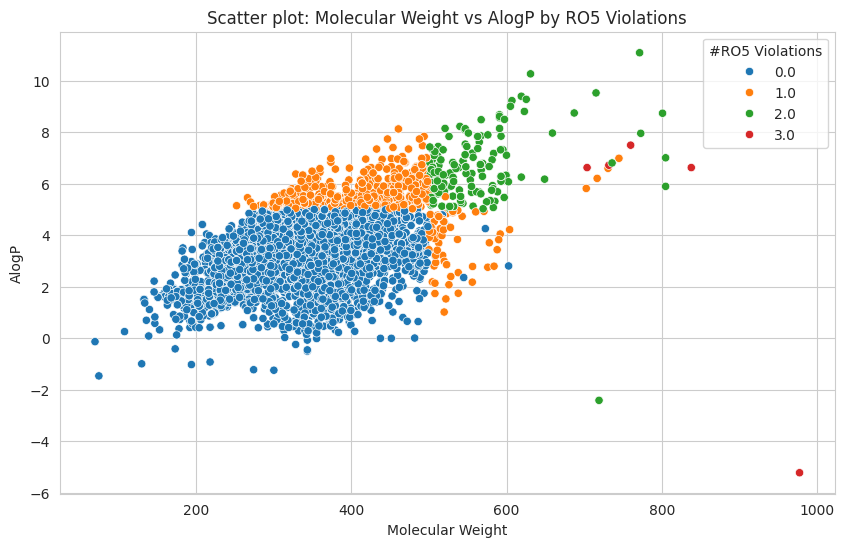

In [ ]:
# MW vs AlogP с цветом по RO5
plt.figure()
sns.scatterplot(data=df_analysis, x='Molecular Weight', y='AlogP', hue='#RO5 Violations')
plt.title('Scatter plot: Molecular Weight vs AlogP by RO5 Violations')
plt.show()

In [ ]:
#Create pie charts to show the proportion of some categories.


VIOLIN PLOTS

Интересный кейс: сравнение распределения активности для Article vs Patent


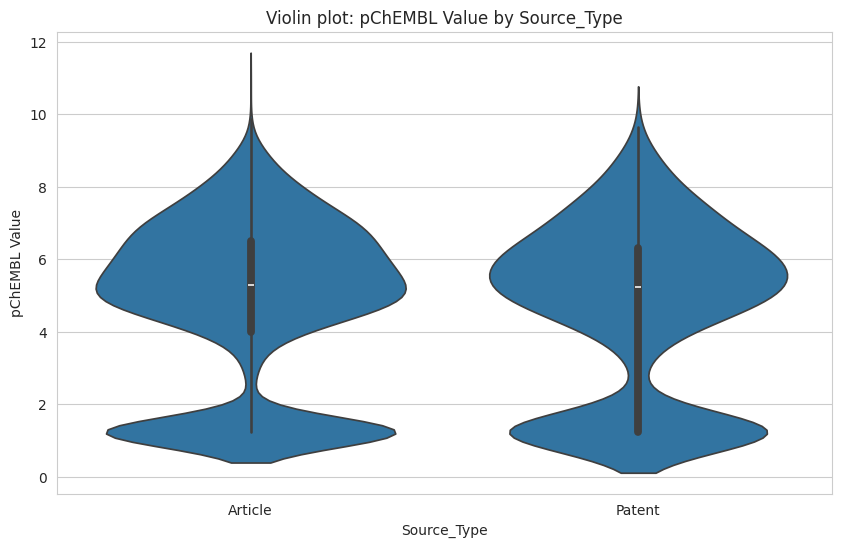

In [ ]:
plt.figure()
sns.violinplot(data=df_analysis, x='Source_Type', y='pChEMBL Value')
plt.title('Violin plot: pChEMBL Value by Source_Type')
plt.show()

QUANTITY / COUNT GRAPHS

/tmp/ipython-input-2815064899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_analysis, x='Document Year', palette='viridis')


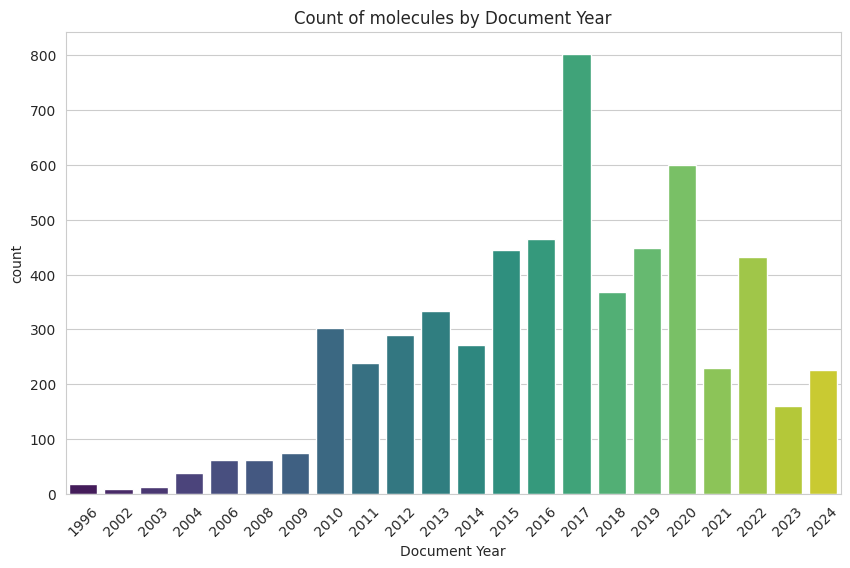

/tmp/ipython-input-2815064899.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_analysis[df_analysis['Journal'].notna()], y='Journal',


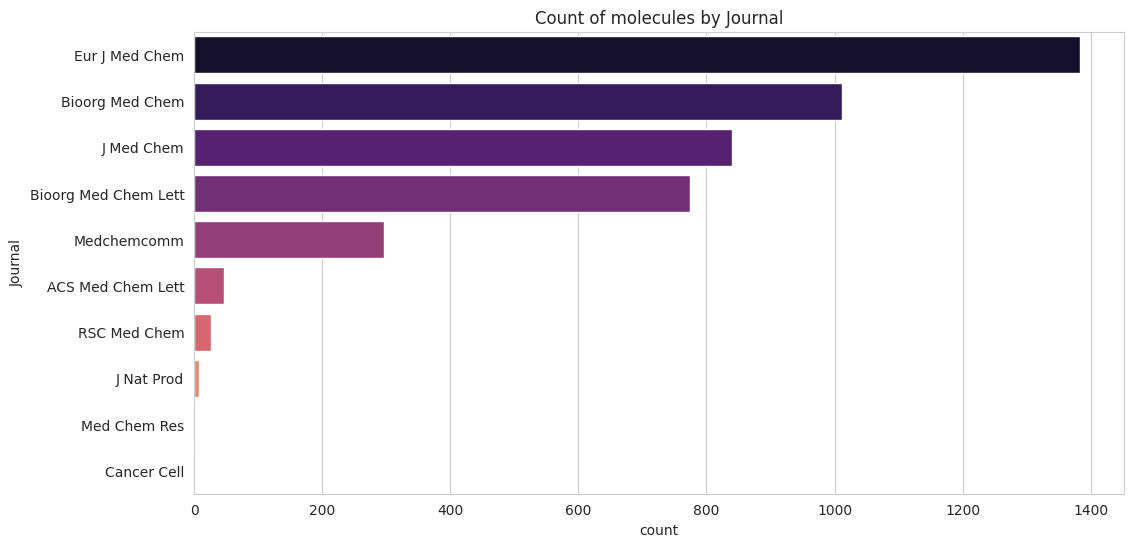

In [ ]:
# Document Year
plt.figure()
sns.countplot(data=df_analysis, x='Document Year', palette='viridis')
plt.title('Count of molecules by Document Year')
plt.xticks(rotation=45)
plt.show()

# Journal (только непустые)
plt.figure(figsize=(12,6))
sns.countplot(data=df_analysis[df_analysis['Journal'].notna()], y='Journal',
              order=df_analysis['Journal'].value_counts().index, palette='magma')
plt.title('Count of molecules by Journal')
plt.show()

CATPLOT

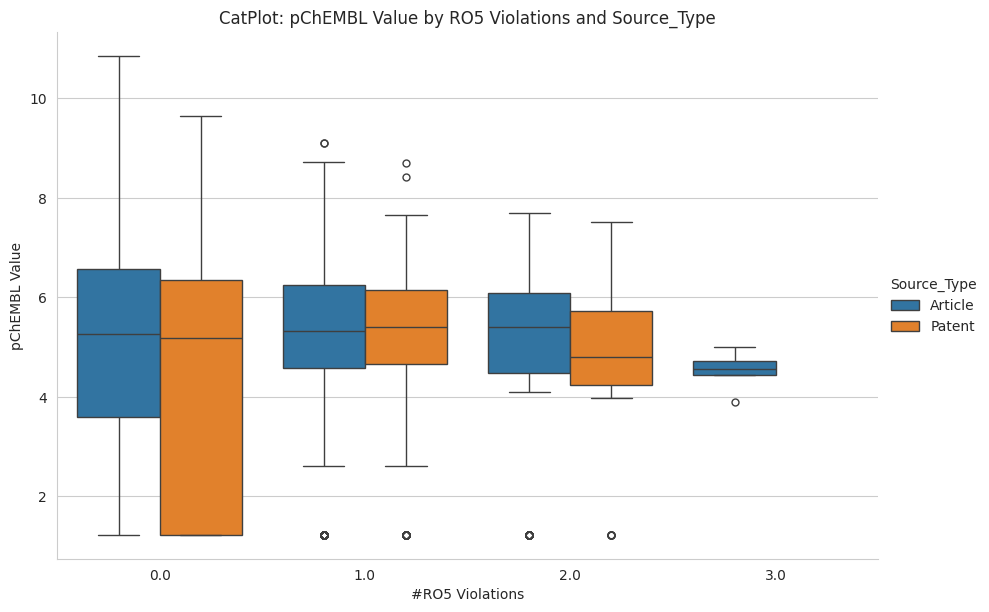

In [ ]:
sns.catplot(data=df_analysis, x='#RO5 Violations', y='pChEMBL Value', hue='Source_Type',
            kind='box', height=6, aspect=1.5)
plt.title('CatPlot: pChEMBL Value by RO5 Violations and Source_Type')
plt.show()

 CORRELATION MATRIX

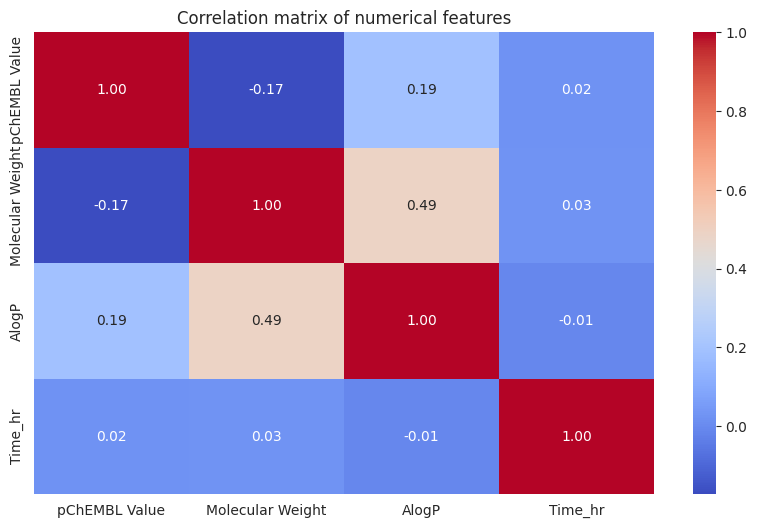

In [ ]:
plt.figure()
corr_matrix = df_analysis[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation matrix of numerical features')
plt.show()

Group Summary

In [ ]:
grouped_stats = df_analysis.groupby(['Document Year', 'Source_Type']).agg(
    pChembl_mean=('pChEMBL Value', 'mean'),
    MW_mean=('Molecular Weight', 'mean'),
    AlogP_mean=('AlogP', 'mean'),
    molecule_count=('Smiles', 'count')
).reset_index()

print("Summary statistics grouped by Document Year and Source Type:")
display(grouped_stats.head())

Summary statistics grouped by Document Year and Source Type:


,Document Year,Source_Type,pChembl_mean,MW_mean,AlogP_mean,molecule_count
0,1996,Article,2.082063,297.345385,3.255385,13
1,1996,Patent,1.773351,345.522500,3.482500,4
2,2002,Article,6.394300,327.205714,3.424286,7
3,2002,Patent,6.199998,340.380000,3.610000,1
4,2003,Article,7.943914,310.092000,2.874000,5


INTERESTING CASES FOR DISCUSSION

RO5 Violation distribution:
 #RO5 Violations
0.0    5053
1.0     658
2.0     168
3.0       5
Name: count, dtype: int64


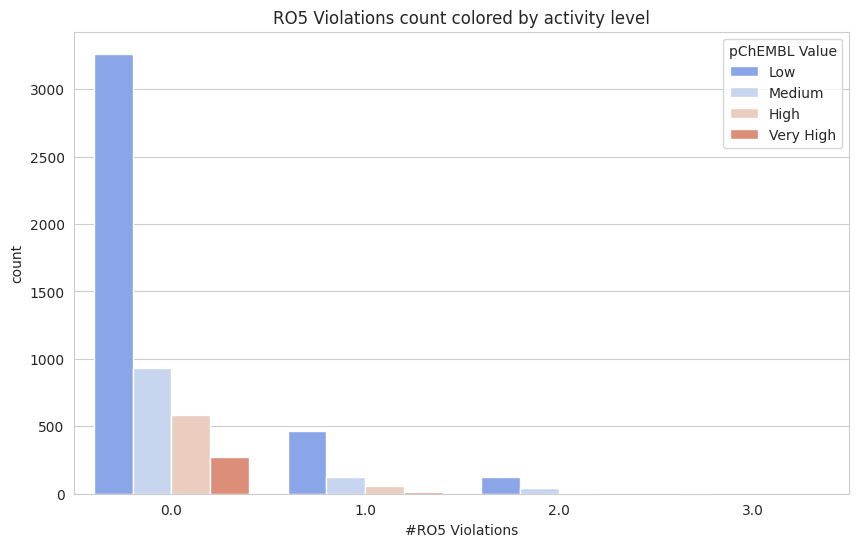

/tmp/ipython-input-3947458933.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=small_high_active, x='Molecular Weight', y='pChEMBL Value', palette='viridis')


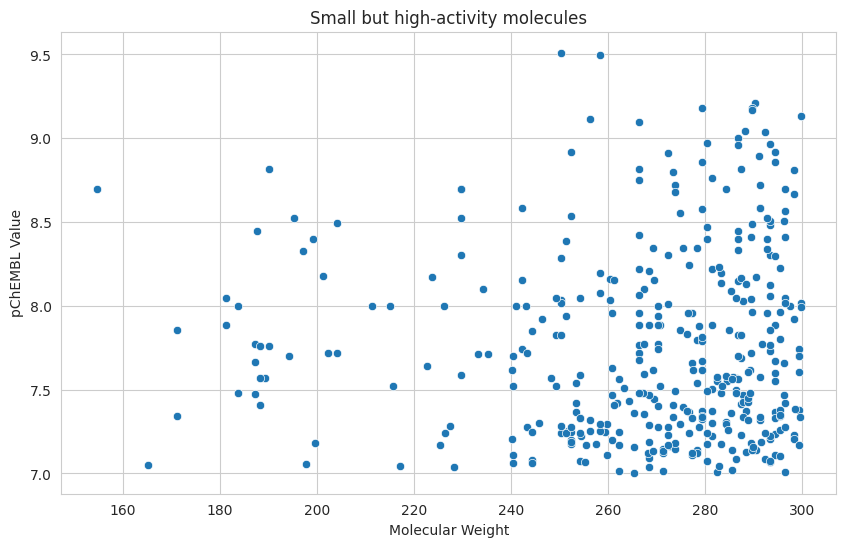

In [ ]:
# 1. Какие RO5 чаще всего нарушаются (0,1,2,3)?
ro5_counts = df_analysis['#RO5 Violations'].value_counts()
print("RO5 Violation distribution:\n", ro5_counts)

sns.countplot(data=df_analysis, x='#RO5 Violations', hue=pd.cut(df_analysis['pChEMBL Value'], bins=[0,6,7,8,10], labels=['Low','Medium','High','Very High']), palette='coolwarm')
plt.title('RO5 Violations count colored by activity level')
plt.show()

small_high_active = df_analysis[(df_analysis['Molecular Weight']<300) & (df_analysis['pChEMBL Value']>7)]
sns.scatterplot(data=small_high_active, x='Molecular Weight', y='pChEMBL Value', palette='viridis')
plt.title('Small but high-activity molecules')
plt.show()

# Модель

Значение pChEMBL = 6 соответствует микромолярному уровню активности (1 μM), который широко используется как стандартный порог для разделения активных и неактивных соединений в базах данных ChEMBL и в задачах виртуального скрининга. В качестве порога классификации был выбран pChEMBL = 6, так как это общепринятый порог для определения биологически значимой активности. Таким образом, задача классификации имеет химически интерпретируемый смысл.

In [ ]:
df_model = df_analysis.copy()

df_model['Activity_Class'] = np.where(
    df_analysis['pChEMBL Value'] >= 6,
    'High',
    'Low'
)

df_model['Activity_Class'].value_counts(normalize=True)


,proportion
Activity_Class,
Low,0.653977
High,0.346023


“После бинаризации таргета с порогом pChEMBL = 6, распределение классов составило примерно 70% низкоактивных и 30% высокоактивных молекул. Такое соотношение не является критически несбалансированным и позволяет применять стандартные классификационные алгоритмы без дополнительных техник балансировки.”

In [ ]:
!pip install -U scikit-learn

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
features = ['Molecular Weight', 'AlogP', '#RO5 Violations']
X = df_model[features]
y = df_model['Activity_Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

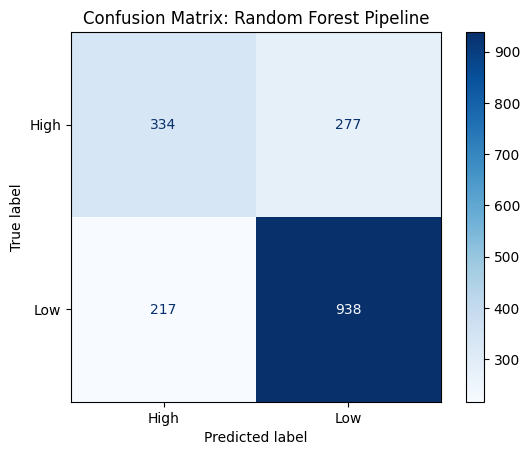

Classification Report:

              precision    recall  f1-score   support

        High       0.61      0.55      0.57       611
         Low       0.77      0.81      0.79      1155

    accuracy                           0.72      1766
   macro avg       0.69      0.68      0.68      1766
weighted avg       0.71      0.72      0.72      1766



In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['High', 'Low'])
disp = ConfusionMatrixDisplay(cm, display_labels=['High', 'Low'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Random Forest Pipeline")
plt.show()

# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['High', 'Low']))


True Negatives (938):
Модель отлично находит низкоактивные соединения. Это самая большая и точная группа.

True Positives (334): Модель верно определила 334 высокоактивных соединения.

Ошибки (Ложноположительные и Ложноотрицательные): 277 случаев: Модель сказала «Low», а на самом деле молекула «High» (пропуск цели).

217 случаев: Модель сказала «High», а на самом деле «Low» (ложная тревога).

Итоговый вывод по модели:

Общая точность (Accuracy) составляет примерно 72% $\frac{334 + 938}{334 + 277 + 217 + 938} \approx 0.72$.Для биологических данных это хороший базовый результат. Модель гораздо лучше предсказывает «плохие» (Low) варианты, чем «хорошие» (High). Это часто случается, если в данных изначально гораздо больше неактивных соединений, чем активных (дисбаланс классов).

In [ ]:
# 7. Cross-validation
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
print(f"5-Fold CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

5-Fold CV Accuracy: 0.659 ± 0.016


/tmp/ipython-input-3620959881.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


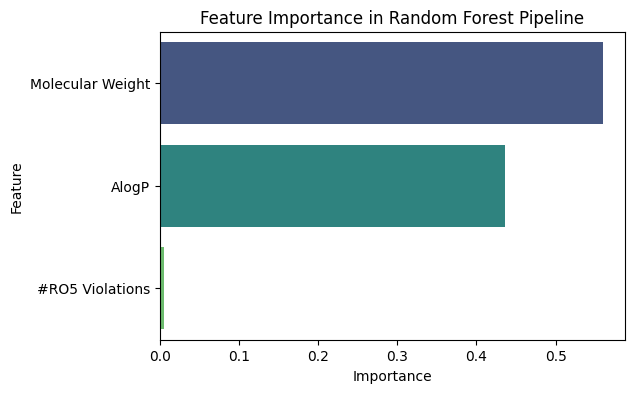

In [ ]:
rf_model = pipeline.named_steps['classifier']
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title("Feature Importance in Random Forest Pipeline")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Forecast

In [ ]:
new_data = pd.DataFrame({
    'Molecular Weight': [300, 450, 500],
    'AlogP': [2.5, 4.1, 1.8],
    '#RO5 Violations': [0, 1, 0]
})

predicted_proba = pipeline.predict_proba(new_data)

threshold = 0.71
predicted_activity = ['High' if prob >= threshold else 'Low'
                      for prob in predicted_proba[:, 1]]
forecast_df = new_data.copy()
forecast_df['Predicted_Activity'] = predicted_activity
forecast_df['Probability_High'] = predicted_proba[:, 1]

forecast_df

,Molecular Weight,AlogP,#RO5 Violations,Predicted_Activity,Probability_High
0,300,2.5,0,High,0.85625
1,450,4.1,1,Low,0.70000
2,500,1.8,0,High,0.85500


Predicted_Activity — это модель сказала: Low.

Probability_High — это вероятность того, что молекула на самом деле High.

Значит модель почти уверена, что они “High”, но стандартный порог классификации стоит на 0.5, и поэтому формально она записала их как Low.

# PCA и Кластеры

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Количество компонент для 90% дисперсии:", X_pca.shape[1])

Количество компонент для 90% дисперсии: 3


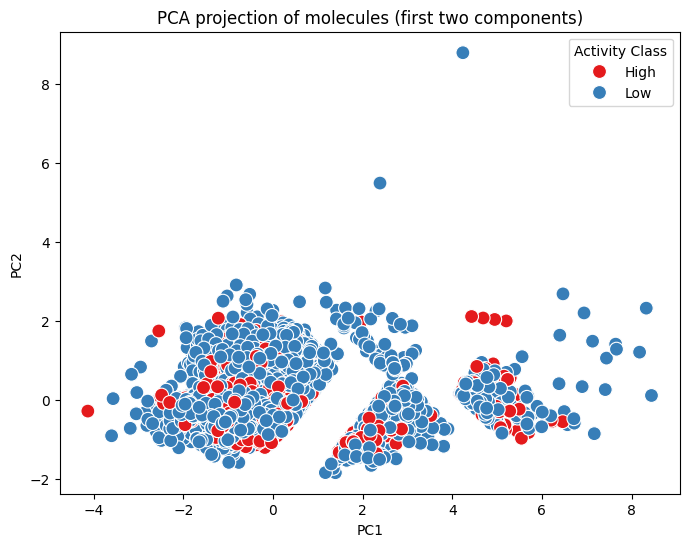

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df_model['Activity_Class'], palette='Set1', s=100)
plt.title("PCA projection of molecules (first two components)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Activity Class")
plt.show()

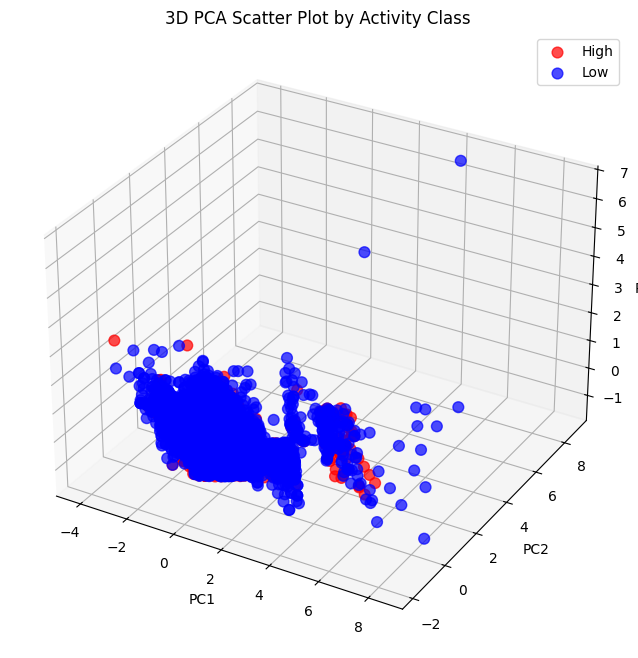

In [ ]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df['Activity_Class'] = df_model['Activity_Class'].values

# 3D scatter plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

colors = {'High':'red', 'Low':'blue'}

for activity in pca_df['Activity_Class'].unique():
    subset = pca_df[pca_df['Activity_Class'] == activity]
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'],
               c=colors[activity], label=activity, s=60, alpha=0.7)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA Scatter Plot by Activity Class')
ax.legend()
plt.show()

In [ ]:
explained_variance = pca.explained_variance_ratio_
print("Доля дисперсии по компонентам:", explained_variance)
print("Суммарная доля дисперсии:", explained_variance.sum())

Доля дисперсии по компонентам: [0.70954777 0.17200335 0.11844888]
Суммарная доля дисперсии: 1.0


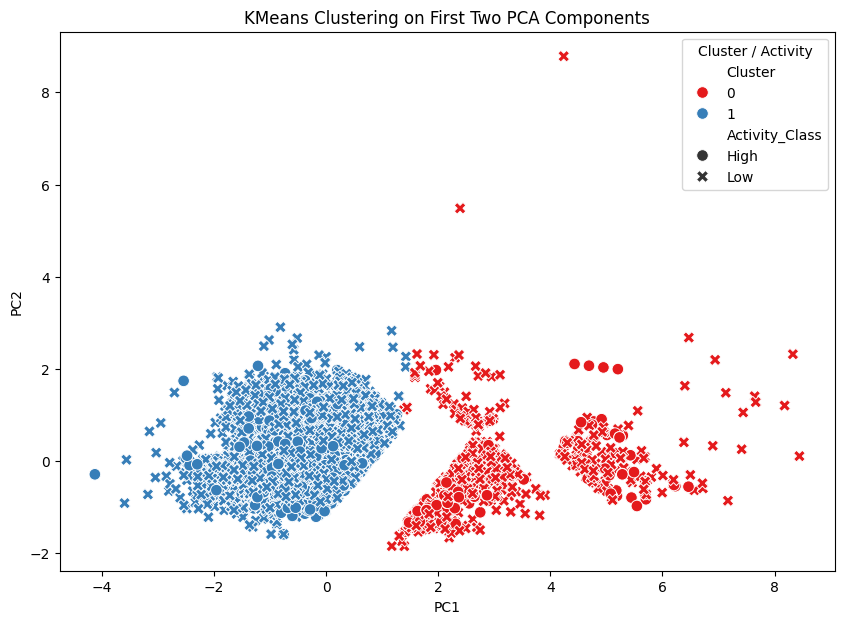

In [ ]:
X_pca_2d = X_pca[:, :2]  # PC1 и PC2
pca_df_2d = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_pca_2d)

pca_df_2d['Cluster'] = clusters
pca_df_2d['Activity_Class'] = df_model['Activity_Class'].values

plt.figure(figsize=(10,7))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster',
    style='Activity_Class',
    palette='Set1',
    s=70,
    data=pca_df_2d
)
plt.title('KMeans Clustering on First Two PCA Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster / Activity')
plt.show()

# Группы???